# Wstępna eksploracyjna analiza danych (EDA) - Etap 2. projektu

Zbiór danych ["Default of Credit Card Clients"](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)


## Krok 1: Weryfikacja jakości i czyszczenie danych

### Wczytanie danych

In [2]:
DATASET_PATH = "../data/default_of_credit_card_clients.xls"

data = pd.read_excel(DATASET_PATH)


In [3]:
data.columns


Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [4]:
data.head()


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


### Zmiana nazw kolumn

In [5]:
### Rename column header to more meaningful variable names ("Description" in the "Variables Table" at the dataset website)
variable_names = data.iloc[0].values
variable_names


array(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
       'PAY_AMT6', 'default payment next month'], dtype=object)

In [6]:
data = data.iloc[1:].copy() # skip the 1st row
data.columns = variable_names
data = data.reset_index(drop=True)

data.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Konwersja i sprawdzenie typów zmiennych

In [7]:
print("Typy danych przed konwersją:")
data.dtypes


Typy danych przed konwersją:


ID                            object
LIMIT_BAL                     object
SEX                           object
EDUCATION                     object
MARRIAGE                      object
AGE                           object
PAY_0                         object
PAY_2                         object
PAY_3                         object
PAY_4                         object
PAY_5                         object
PAY_6                         object
BILL_AMT1                     object
BILL_AMT2                     object
BILL_AMT3                     object
BILL_AMT4                     object
BILL_AMT5                     object
BILL_AMT6                     object
PAY_AMT1                      object
PAY_AMT2                      object
PAY_AMT3                      object
PAY_AMT4                      object
PAY_AMT5                      object
PAY_AMT6                      object
default payment next month    object
dtype: object

In [8]:
# Infer column types based on column values
data = data.infer_objects()

# set the type of the last variable (target) to bool
data = data.astype({variable_names[-1]: bool})


In [9]:
print(f"Typy danych po konwersji:\n{data.dtypes}")


Typy danych po konwersji:
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month     bool
dtype: object


### Sprawdzenie struktury zbioru danych

In [10]:
print(f"Zbiór danych zawiera {data.shape[0]} wierszy i {data.shape[1]} kolumn")


Zbiór danych zawiera 30000 wierszy i 25 kolumn


### Sprawdzenie brakujących wartości i zduplikowanych wierszy

In [11]:
# Sprawdzenie czy zbiór danych zawiera brakujące wartości (NaN)
missing = data.isnull().sum()
missing_result = "nie zawiera" if missing.sum() == 0 else f"zawiera {missing.sum()}"

print(f"Zbiór danych {missing_result} brakujących wartości")

Zbiór danych nie zawiera brakujących wartości


In [12]:
# Sprawdzenie czy zbiór danych zawiera zduplikowane wiersze
duplicated = data.duplicated().sum()
duplicated_result = "nie zawiera" if duplicated == 0 else f"zawiera {duplicated}"

print(f"Zbior danych {duplicated_result} zduplikowanych wierszy")

Zbior danych nie zawiera zduplikowanych wierszy


### Znaczenie kolumn w zbiorze danych

Wszystkie kwoty są podane w dolarach tajwańskich


| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X1             | LIMIT_BAL | Kwota udzielonego kredytu |
| X2             | SEX | Płeć (1 = mężczyzna, 2 = kobieta) |
| X3             | EDUCATION | Wykształcenie (1 = studia podyplomowe, 2 = studia wyższe, 3 = szkoła średnia, 4 = inne) |
| X4             | MARRIAGE | Stan cywilny (1 = married, 2 = single, 3 = others) |
| X5             | AGE | Wiek |


Zmienne **X6 - X11**: Historia spłat (od kwietnia do września 2005r.)

Status spłaty (-1 = spłata terminowa, 1 = opóżnienie płatności o jeden miesiąc, 2 = opóżnienie płatności o dwa miesiące, ..., 8 = opóźnienie płatności o osiem miesięcy, 9 = opóźnienie płatności o dziewięć miesięcy i więcej)

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X6             | PAY_0 | Status spłaty we wrześniu 2005r. |
| X7             | PAY_2 | Status spłaty w sierpniu 2005r. |
| X8             | PAY_3 | Status spłaty w lipcu 2005r. |
| X9             | PAY_4 | Status spłaty w czerwcu 2005r. |
| X10            | PAY_5 | Status spłaty w maju 2005r. |
| X11            | PAY_6 | Status spłaty w kwietniu 2005r. |


Zmienne **X12 - X17**: Kwota rachunku (od kwietnia do września 2005r.)

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X12            | BILL_AMT1 | Kwota rachunku we wrześniu 2005r. |
| X13            | BILL_AMT2 | Kwota rachunku w sierpniu 2005r. |
| X14            | BILL_AMT3 | Kwota rachunku w lipcu 2005r. |
| X15            | BILL_AMT4 | Kwota rachunku w czerwcu 2005r. |
| X16            | BILL_AMT5 | Kwota rachunku w maju 2005r.|
| X17            | BILL_AMT6 | Kwota rachunku w kwietniu 2005r. |

Zmienne **X18 - X23**: Kwota poprzedniej płatności (od kwietnia do września 2005r.)

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X18            | PAY_AMT1 | Kwota zapłacona we wrześniu 2005r. |
| X19            | PAY_AMT2 | Kwota zapłacona w sierpniu 2005r. |
| X20            | PAY_AMT3 | Kwota zapłacona w lipcu 2005r. |
| X21            | PAY_AMT4 | Kwota zapłacona w czerwcu 2005r. |
| X22            | PAY_AMT5 | Kwota zapłacona w maju 2005r. |
| X23            | PAY_AMT6 | Kwota zapłacona w kwietniu 2005r. |

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| Y              | default payment next month | Zaległość w spłacie (1 = Tak, 0 = Nie) |

### Sprawdzenie potencjalnych błędów w zmiennych kategorycznych

In [13]:
def find_not_allowed_values(dataset: pd.DataFrame, feature_name: str, allowed_values: list) -> pd.DataFrame:
    """
    Find all values in the specified feature (feature_name) that are not allowed in a dataset (allowed_values)
    :param dataset:
    :param feature_name:
    :param allowed_values:
    :return: DataFrame containing all non-allowed values
    """
    values_raw = pd.DataFrame(dataset[feature_name].value_counts()).T.columns.tolist()
    not_allowed_values = data[~data[feature_name].isin(allowed_values)]
    return not_allowed_values


#### Cecha Sex - #2 Zmienna

In [14]:
variable_names[2]


'SEX'

In [15]:
# Dozwolony zakres wartości dla danej cechy (1 = male; 2 = female)
sex_value_valid_range = [1, 2]

# Sprawdzenie wartości dla cechy SEX
sex_values_raw = pd.DataFrame(data[variable_names[2]].value_counts()).T
sex_values = sex_values_raw.rename(columns={1: "Male (1)", 2: "Female (2)"}, inplace=False)

print(sex_values)


SEX    Female (2)  Male (1)
count       18112     11888


In [16]:
# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
sex_not_allowed_values = find_not_allowed_values(
    dataset=data,
    feature_name=variable_names[2],
    allowed_values=sex_value_valid_range)

if not sex_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy {variable_names[2]}")
    print(sex_not_allowed_values)


#### Cecha EDUCATION - #3 Zmienna

In [17]:
variable_names[3]


'EDUCATION'

In [18]:
# Dozwolony zakres wartości dla danej cechy (1 = graduate school; 2 = university; 3 = high school; 4 = others)
education_value_valid_range = [1,2, 3, 4]

# Sprawdzenie wartości dla cechy EDUCATION (Education Level)
education_values_raw = pd.DataFrame(data[variable_names[3]].value_counts()).T
education_values = education_values_raw.rename(columns={1: "graduate school (1)", 2: "university (2)", 3: "high school (3)", 4: "others (4)"}, inplace=False)

print(education_values)


EDUCATION  university (2)  graduate school (1)  high school (3)    5  \
count               14030                10585             4917  280   

EDUCATION  others (4)   6   0  
count             123  51  14  


In [19]:
# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
education_not_allowed_values = find_not_allowed_values(
    dataset=data,
    feature_name=variable_names[3],
    allowed_values=education_value_valid_range)

if not education_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy {variable_names[3]} (Education Level)")
    display(education_not_allowed_values)


Dane dla nieprawidłowych wartości cechy EDUCATION (Education Level)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
47,48,150000,2,5,2,46,0,0,-1,0,0,-2,4463,3034,1170,1170,0,0,1013,1170,0,0,0,0,True
69,70,20000,1,5,2,22,2,0,0,0,0,0,18565,17204,17285,18085,11205,5982,0,1200,1000,500,1000,0,False
385,386,410000,2,5,1,42,0,0,0,0,0,0,338106,342904,344464,240865,234939,240176,15000,14000,9000,8500,9000,8300,False
502,503,230000,2,6,2,46,0,0,0,0,0,0,221590,227397,230302,186635,189896,193351,10000,9000,8000,8000,7500,7000,False
504,505,30000,1,6,1,53,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29811,29812,50000,1,5,2,46,0,0,0,-1,0,0,49336,49623,19900,19183,19563,19157,1423,1000,19183,687,696,776,False
29836,29837,180000,1,6,1,34,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,False
29839,29840,150000,1,5,1,36,0,0,0,0,0,0,216482,220889,133616,136378,139219,142172,5500,3800,3900,4000,4100,4100,False
29920,29921,50000,1,5,1,45,2,0,0,0,0,0,71927,73514,75373,50947,51020,0,3000,3428,2002,1023,0,0,True


#### Cecha X4 (Marital Status)

In [20]:
variable_names[4]


'MARRIAGE'

In [21]:
# Dozwolony zakres wartości dla danej cechy (1 = married; 2 = single; 3 = others)
marital_status_value_valid_range = [1,2, 3]

# Sprawdzenie wartości dla cechy MARRIAGE (Marital status )
marital_status_values = pd.DataFrame(data[variable_names[4]].value_counts()).T
marital_status_values.rename(columns={1: "married (1)", 2: "single (2)", 3: "others (3)"}, inplace=True)

print(marital_status_values)


MARRIAGE  single (2)  married (1)  others (3)   0
count          15964        13659         323  54


In [22]:
# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
marital_status_not_allowed_values = find_not_allowed_values(
    dataset=data,
    feature_name=variable_names[4],
    allowed_values=marital_status_value_valid_range)

if not marital_status_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy {variable_names[4]} (Marital Status)")
    display(marital_status_not_allowed_values)


Dane dla nieprawidłowych wartości cechy MARRIAGE (Marital Status)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
218,219,110000,2,3,0,31,0,0,0,0,0,0,89989,84229,79288,73315,63818,63208,4000,5000,3000,3000,3000,8954,False
809,810,160000,2,2,0,37,0,0,0,0,0,0,2694,38433,38870,28574,27268,28021,35888,1325,891,1000,1098,426,False
820,821,200000,2,3,0,51,-1,-1,-1,-1,0,-1,780,0,390,780,390,390,0,390,780,0,390,390,False
1019,1020,180000,2,3,0,45,-1,-1,-2,-2,-2,-2,4148,0,0,0,0,0,0,0,0,0,0,0,False
1443,1444,200000,1,3,0,51,-1,-1,-1,-1,0,-1,3556,4993,9212,2529,1036,4430,5020,9236,2529,0,4430,6398,False
2146,2147,150000,2,3,0,55,-1,-1,-1,-1,-1,-1,1080,17493,9160,2939,3396,1870,17498,9160,2939,3396,1870,6800,False
2554,2555,220000,2,1,0,33,-1,-1,-1,-1,-1,-1,3378,1531,942,608,1738,277,1531,942,608,1738,277,492,False
3056,3057,200000,1,3,0,36,-2,-2,-2,-2,-2,-2,5644,82620,14129,41359,9140,0,89187,14178,41359,9140,0,0,False
4470,4471,70000,1,3,0,35,2,2,2,2,2,2,47702,48839,49636,50517,51658,52758,2200,1900,2000,2100,2100,2000,False
5005,5006,90000,2,3,0,24,-2,-2,-2,-1,0,0,3700,20833,23968,13574,6800,1830,20108,4000,13574,14,5,13162,False


#### Cechy PAY_0, PAY_2 .. PAY_6 - Zmienne #6-#11 (Statusy Spłat)

In [23]:
# Statusy spłat - Historia spłat (od kwietnia do września 2005r.)
payment_history_features = [variable_names[i] for i in range(6, 12)]
payment_history_features


['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [24]:
# Dozwolony zakres wartości dla danej cechy:
# -1 = spłata terminowa,
# 1 = opóżnienie płatności o jeden miesiąc,
# 2 = opóżnienie płatności o dwa miesiące,
# .
# .
# .
# 8 = opóźnienie płatności o osiem miesięcy,
# 9 = opóźnienie płatności o dziewięć miesięcy i więcej
payment_status_value_valid_range = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [25]:
# Sprawdzenie wartości dla cech PAY_X (Statusy spłat)
for feature_name in payment_history_features:
    feature_values_raw = pd.DataFrame(data[feature_name].value_counts()).T
    # feature_values = feature_values_raw.rename(
    #     columns={-1: "pay duly (-1)", 1: "1 month delay (1)",2: "2 months delay (2)",
    #              3: "3 months delay (3)", 4: "4 months delay (4)", 5: "5 months delay (5)",
    #              6: "6 months delay (6)", 7: "7 months delay (7)", 8: "8 months delay (8)",
    #              9: "9 months and above delay (9)"}, inplace=False)

    print(feature_values_raw.T.sort_values(feature_name).T)
    print("\n")


PAY_0    -2    -1      0     1     2    3   4   5   6   7   8
count  2759  5686  14737  3688  2667  322  76  26  11   9  19


PAY_2    -2    -1      0   1     2    3   4   5   6   7   8
count  3782  6050  15730  28  3927  326  99  25  12  20   1


PAY_3    -2    -1      0   1     2    3   4   5   6   7   8
count  4085  5938  15764   4  3819  240  76  21  23  27   3


PAY_4    -2    -1      0   1     2    3   4   5   6   7   8
count  4348  5687  16455   2  3159  180  69  35   5  58   2


PAY_5    -2    -1      0     2    3   4   5   6   7   8
count  4546  5539  16947  2626  178  84  17   4  58   1


PAY_6    -2    -1      0     2    3   4   5   6   7   8
count  4895  5740  16286  2766  184  49  13  19  46   2




In [26]:
# Znaleznie wartości niedozwolonych w cechach X6-X11

# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
for feature_name in payment_history_features:
    feature_not_allowed_values = find_not_allowed_values(
        dataset=data,
        feature_name=feature_name,
        allowed_values=payment_status_value_valid_range)

    if not feature_not_allowed_values.empty:
        print(f"Dane dla nieprawidłowych wartości cechy {feature_name}")
        display(feature_not_allowed_values)
        print("=" * 50, "\n")


Dane dla nieprawidłowych wartości cechy PAY_0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
7,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29990,29991,140000,1,2,1,41,0,0,0,0,0,0,138325,137142,139110,138262,49675,46121,6000,7000,4228,1505,2000,2000,False
29992,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29993,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False



Dane dla nieprawidłowych wartości cechy PAY_2


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29988,29989,250000,1,1,1,34,0,0,0,0,0,0,279640,252913,243075,245750,175005,179687,65000,8800,9011,6000,7000,6009,False
29990,29991,140000,1,2,1,41,0,0,0,0,0,0,138325,137142,139110,138262,49675,46121,6000,7000,4228,1505,2000,2000,False
29992,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False



Dane dla nieprawidłowych wartości cechy PAY_3


...

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29992,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29993,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,True



Dane dla nieprawidłowych wartości cechy PAY_5


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,False
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,True
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,True



Dane dla nieprawidłowych wartości cechy PAY_6


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29993,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,False
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,True


### Data Cleaning

In [27]:
# Czyszczenie zmiennej EDUCATION (Education Level)
# utworzenie nowej czystej zmiennej - zamiana 0, 5, 6 na 4 (inne)
data[f"{variable_names[3]}_CLEAN"] = data[variable_names[3]].replace({0: 4, 5: 4, 6: 4})

# Czyszczenie zmiennej MARRIAGE (Marital Status)
# utworzenie nowej czystej zmiennej - zamiana 0 na 3 (inne)
data[f"{variable_names[4]}_CLEAN"] = data[variable_names[4]].replace({0: 3})

# Zapisanie nazw oczyszczonych zmiennych kategorycznych
cleaned_categorical_variable_names = []
cleaned_categorical_variable_names.append(f"{variable_names[3]}_CLEAN")
cleaned_categorical_variable_names.append(f"{variable_names[4]}_CLEAN")

# Sprawdzenie czy operacja się powiodła
print(f"Wartości po czyszczeniu {variable_names[3]} (nowa oczyszczona zmienna [{f"{variable_names[3]}_CLEAN"}]):",
      data[f"{variable_names[3]}_CLEAN"].sort_values().unique())
print(f"Wartości po czyszczeniu {variable_names[4]} (nowa oczyszczona zmienna [{f"{variable_names[4]}_CLEAN"}]):",
      data[f"{variable_names[4]}_CLEAN"].sort_values().unique())


Wartości po czyszczeniu EDUCATION (nowa oczyszczona zmienna [EDUCATION_CLEAN]): [1 2 3 4]
Wartości po czyszczeniu MARRIAGE (nowa oczyszczona zmienna [MARRIAGE_CLEAN]): [1 2 3]


## Krok 2: Statystyki opisowe

In [28]:
# Zmienne nienumeryczne - ID, zmienne kategoryczne, zmienna docelowa (default payment next month)
not_numeric_cols = [variable_names[i] for i in range(0, 5) if i != 1]
not_numeric_cols += payment_history_features
not_numeric_cols.append(variable_names[-1])
not_numeric_cols


['ID',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'default payment next month']

In [29]:
# Zmienne numeryczne
numeric_cols = data.drop(not_numeric_cols + cleaned_categorical_variable_names, axis=1).columns.tolist()
numeric_cols


['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [30]:
# Statystyki dla zmiennych numerycznych
numeric_stat = data[numeric_cols].describe().T
numeric_stat


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


## Krok 3: Analiza rozkładów i wartości odstających (Wizualizacje)

### Analiza rozkładów zmiennych

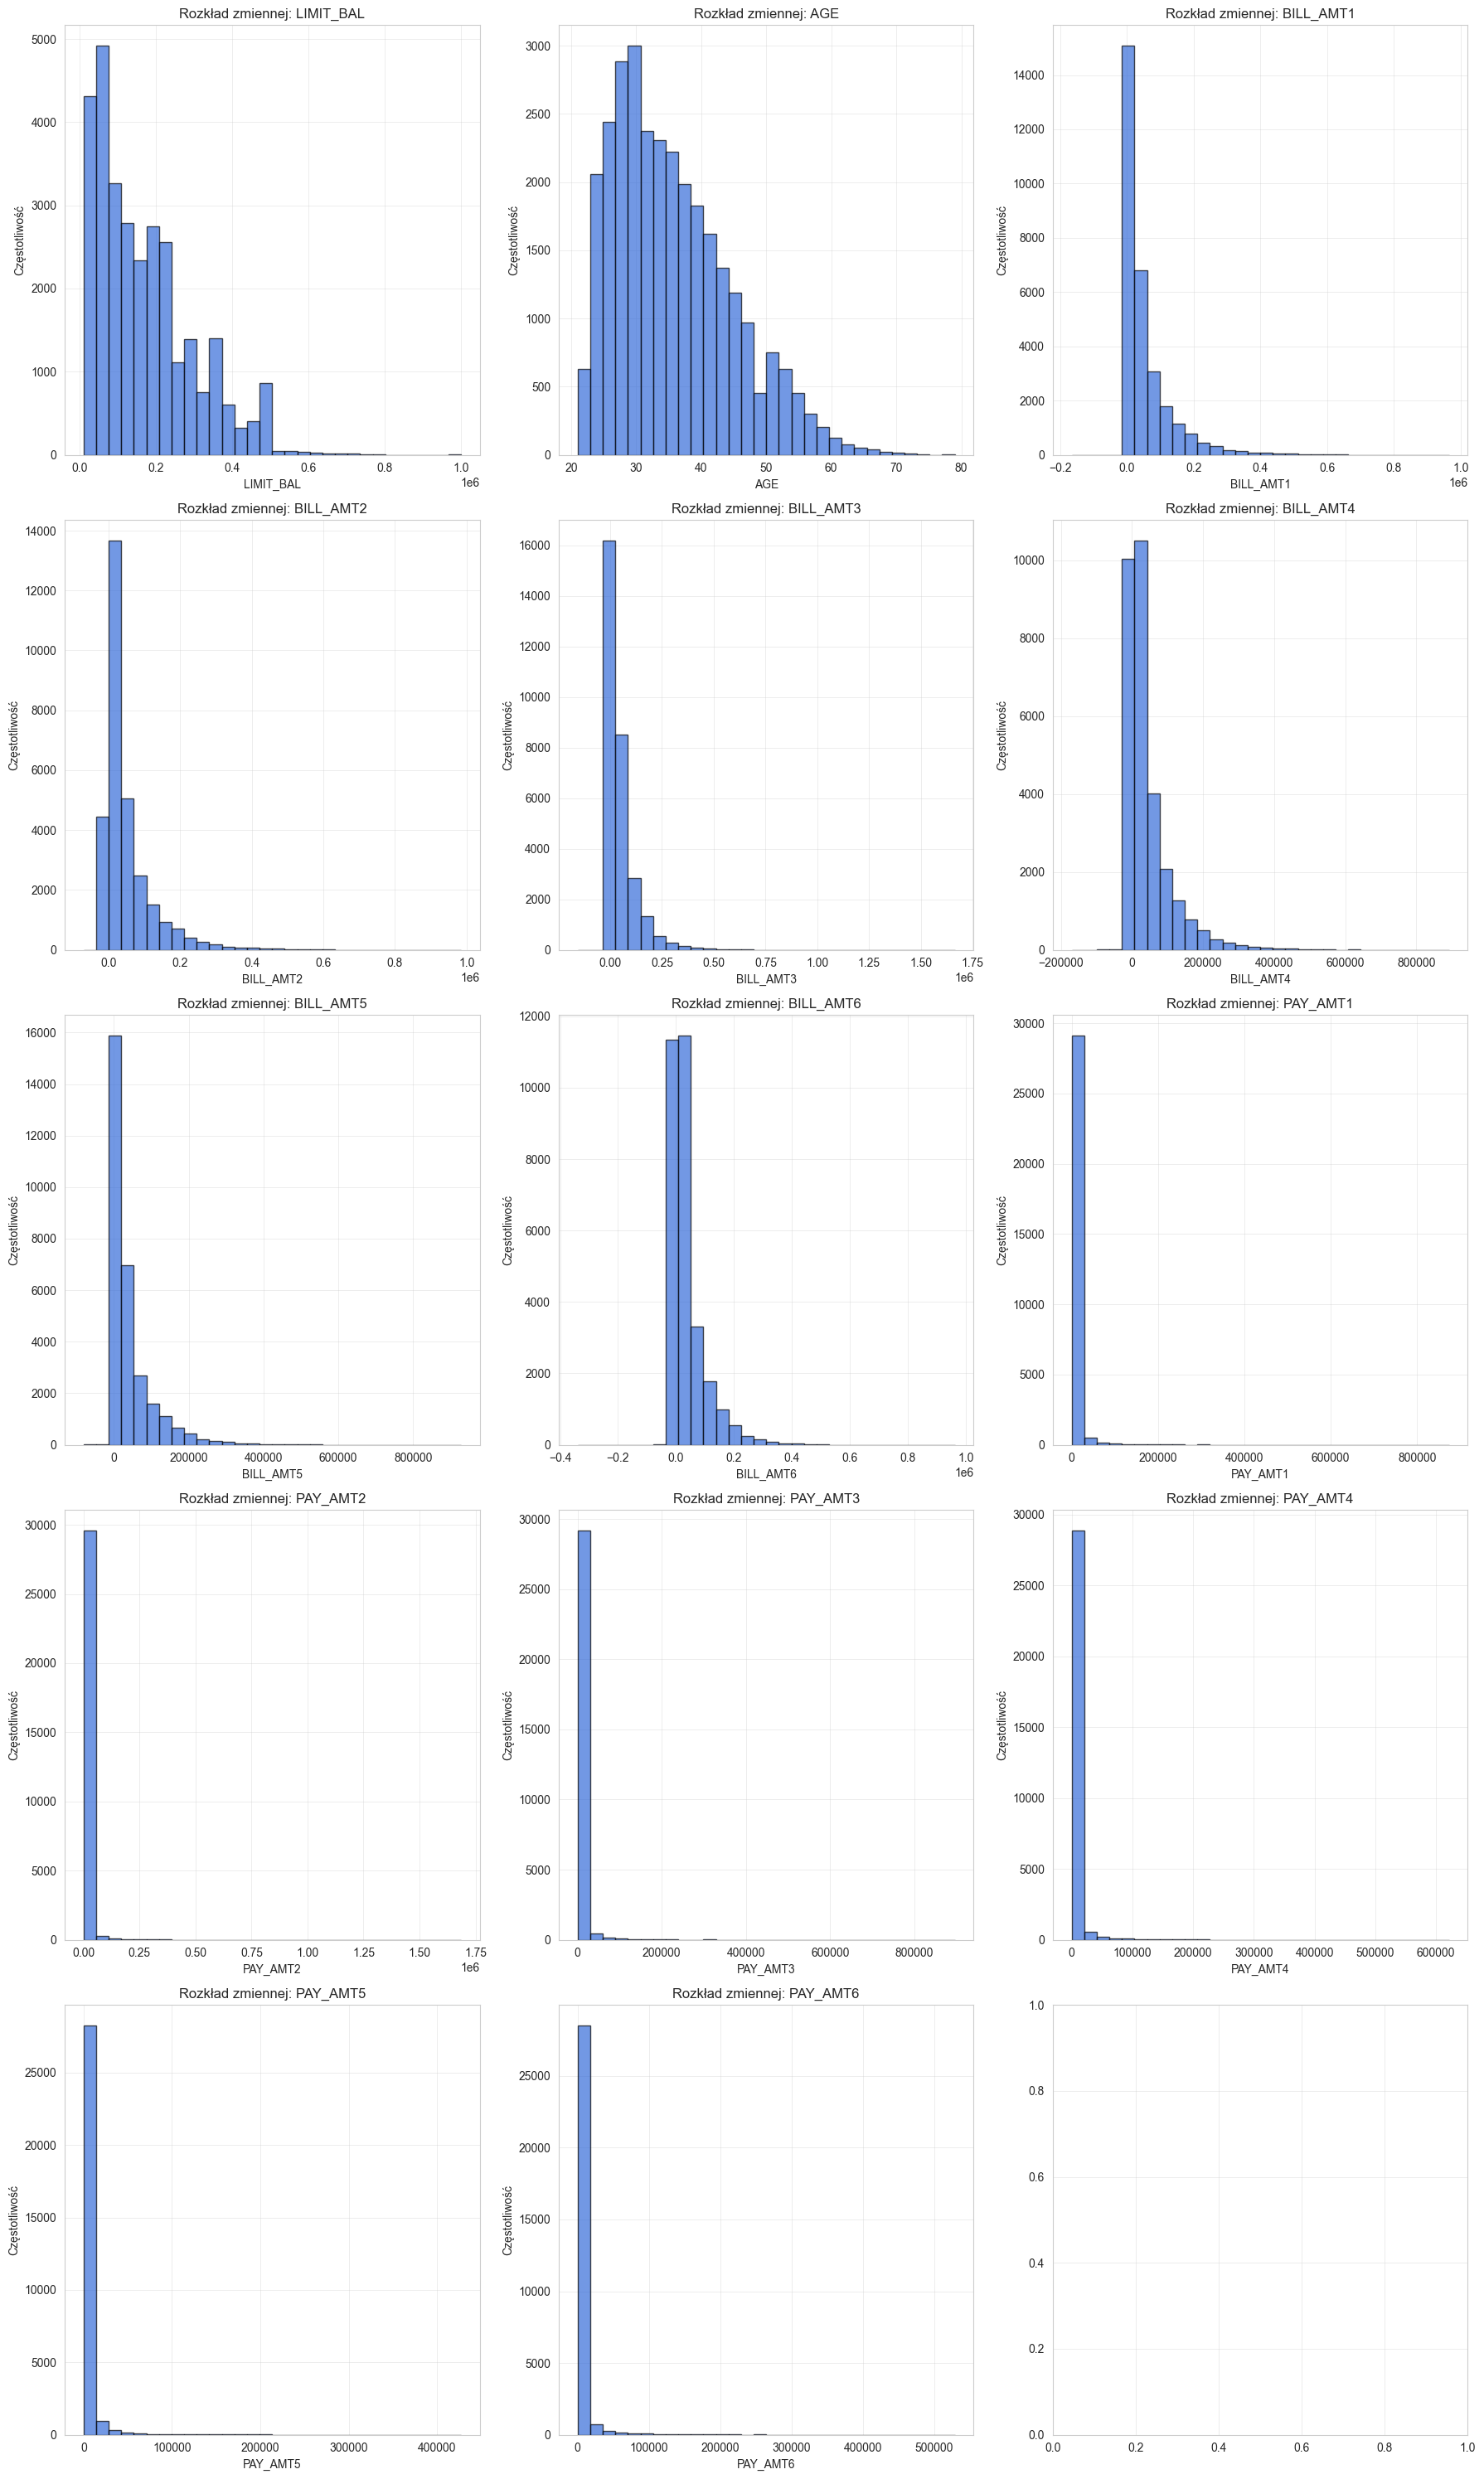

In [31]:
# Histogramy dla zmiennych numerycznych
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

rows = len(numeric_cols) // 3

fig, axes = plt.subplots(rows + 1, 3, figsize=(18, 30))
axes = axes.flatten()

for i, var in enumerate(numeric_cols):
    if var in data.columns:
        axes[i].hist(data[var], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f"Rozkład zmiennej: {var}")
        axes[i].set_xlabel(var)
        axes[i].set_ylabel("Częstotliwość")

plt.tight_layout()
plt.show()

# previous_payment_cols = ["X18", "X19", "X20", "X21", "X22", "X23"]

### Identyfikacja wartości odstających (outliers)

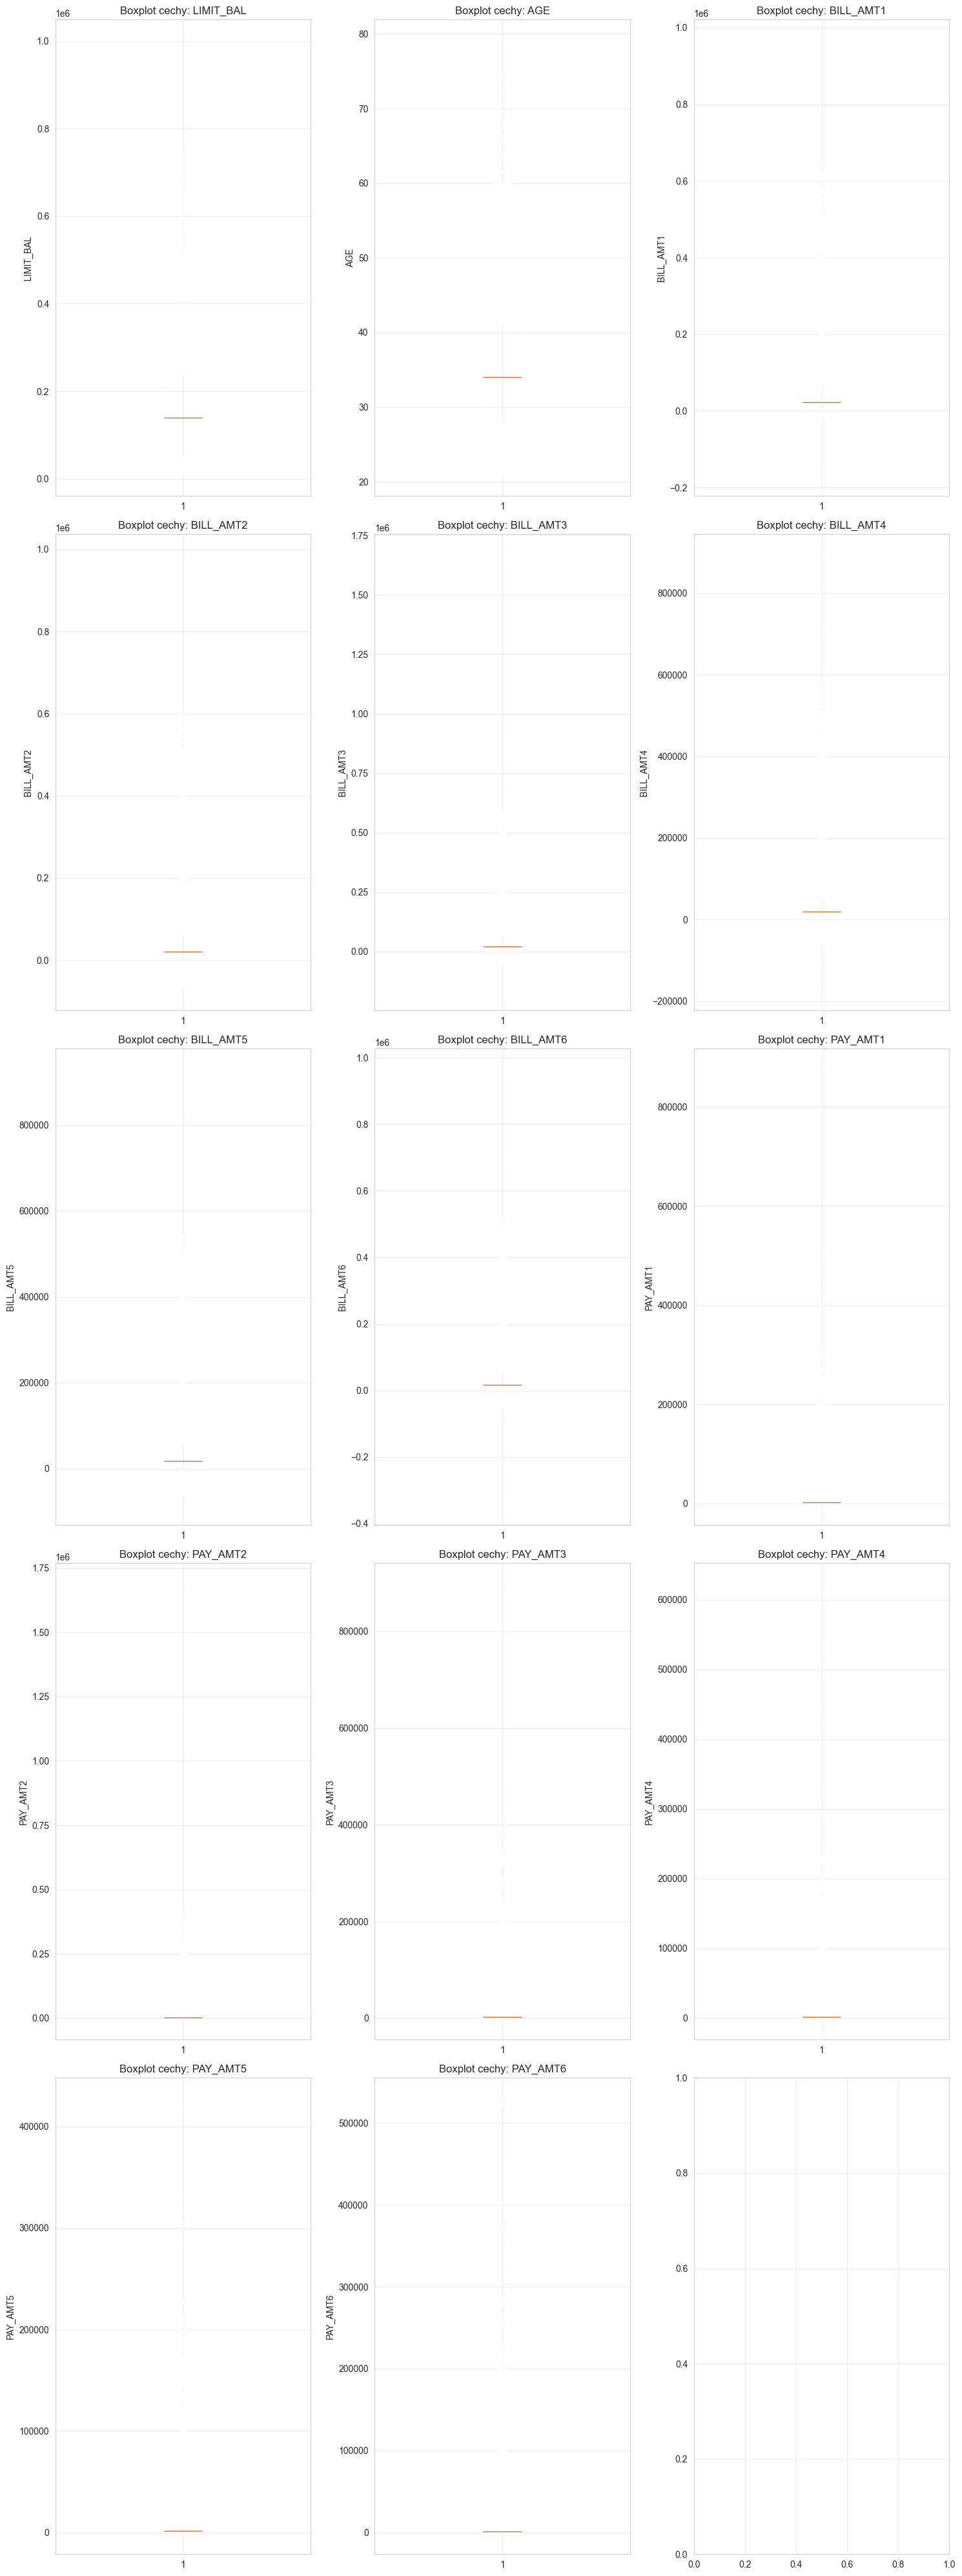

In [32]:
# Boxploty dla zmiennych numerycznych
fig, axes = plt.subplots(rows + 1, 3, figsize=(15, 40))
axes = axes.flatten()

# outlier_vars = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2']
for i, var in enumerate(numeric_cols):
    if var in data.columns:
        axes[i].boxplot(data[var])
        axes[i].set_title(f'Boxplot cechy: {var}')
        axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


In [33]:
# Metoda IQR do wykrywania outlierów
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Liczba outlierów (metodą IQR):")
for col in numeric_cols:
    if col in data.columns:
        n_outliers, low, high = count_outliers_iqr(data, col)
        print(f"{col}: {n_outliers} outlierów (zakres: {low:.2f} - {high:.2f})")


Liczba outlierów (metodą IQR):
LIMIT_BAL: 167 outlierów (zakres: -235000.00 - 525000.00)
AGE: 272 outlierów (zakres: 8.50 - 60.50)
BILL_AMT1: 2400 outlierów (zakres: -91739.62 - 162389.38)
BILL_AMT2: 2395 outlierów (zakres: -88547.50 - 155538.50)
BILL_AMT3: 2469 outlierów (zakres: -83581.50 - 146412.50)
BILL_AMT4: 2622 outlierów (zakres: -75942.12 - 132774.88)
BILL_AMT5: 2725 outlierów (zakres: -70878.25 - 122831.75)
BILL_AMT6: 2693 outlierów (zakres: -70657.38 - 121111.62)
PAY_AMT1: 2745 outlierów (zakres: -5009.00 - 11015.00)
PAY_AMT2: 2714 outlierów (zakres: -5417.50 - 11250.50)
PAY_AMT3: 2598 outlierów (zakres: -5782.50 - 10677.50)
PAY_AMT4: 2994 outlierów (zakres: -5279.88 - 9589.12)
PAY_AMT5: 2945 outlierów (zakres: -5416.00 - 9700.00)
PAY_AMT6: 2958 outlierów (zakres: -5705.62 - 9823.38)


### Wykresy rozrzutu (Scatter plots)

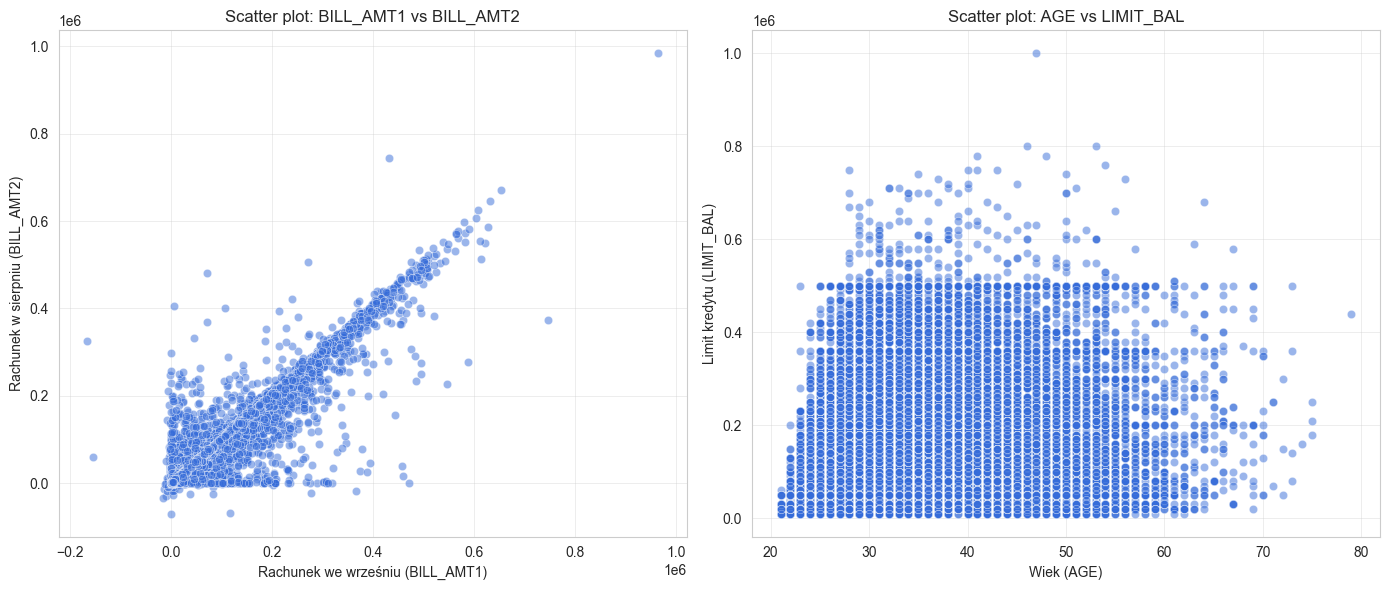

In [34]:
# Wykresy rozrzutu (Scatter plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Przykład 1: Silna korelacja (kwoty rachunków w kolejnych miesiącach)
sns.scatterplot(x=variable_names[12], y=variable_names[13], data=data, alpha=0.5, ax=axes[0])
axes[0].set_title(f'Scatter plot: {variable_names[12]} vs {variable_names[13]}')
axes[0].set_xlabel(f'Rachunek we wrześniu ({variable_names[12]})')
axes[0].set_ylabel(f'Rachunek w sierpniu ({variable_names[13]})')

# Przykład 2: Brak korelacji (Wiek vs Kwota udzielonego kredytu)
sns.scatterplot(x=variable_names[5], y=variable_names[1], data=data, alpha=0.5, ax=axes[1])
axes[1].set_title(f'Scatter plot: {variable_names[5]} vs {variable_names[1]}')
axes[1].set_xlabel(f'Wiek ({variable_names[5]})')
axes[1].set_ylabel(f'Limit kredytu ({variable_names[1]})')

plt.tight_layout()
plt.show()


## Krok 4: Analiza zależności między zmiennymi (korelacje)

In [35]:
# Zmienne dla których będzie wyliczona korelacja
selected_for_corr = numeric_cols + payment_history_features
selected_for_corr.append(variable_names[-1]) # target

selected_for_corr


['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'default payment next month']

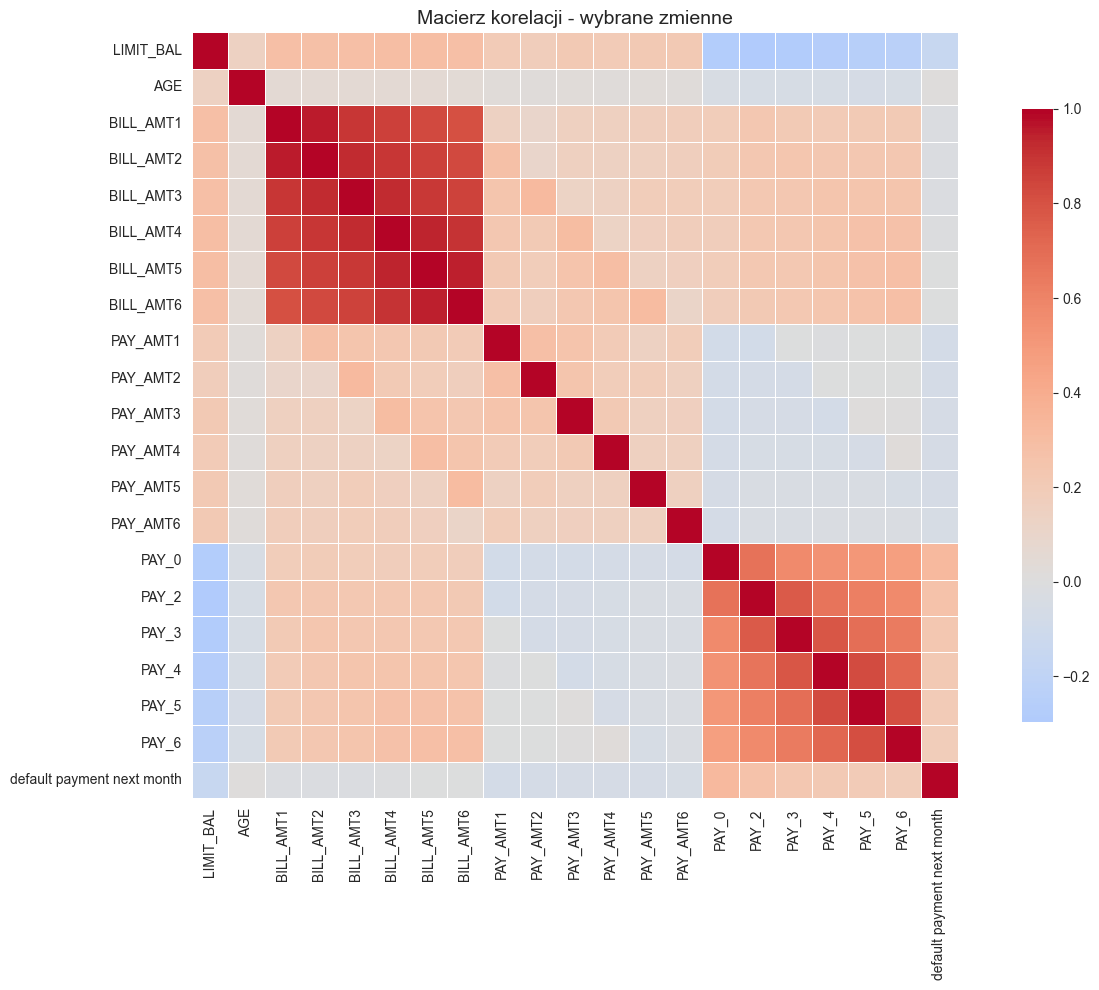

In [36]:
# Macierz korelacji dla wybranych zmiennych
corr_matrix = data[selected_for_corr].corr()

# Heatmapa korelacji
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Macierz korelacji - wybrane zmienne', fontsize=14)
plt.tight_layout()
plt.show()


In [37]:
# Najsilniejsze korelacje ze zmienną docelową
target_corr = corr_matrix[variable_names[-1]].sort_values(ascending=False)

print(f"\nKorelacje ze zmienną docelową ({variable_names[-1]}):")
print(target_corr.drop(labels=[variable_names[-1]]))



Korelacje ze zmienną docelową (default payment next month):
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default payment next month, dtype: float64


## Krok 5: Wstępne obserwacje (Wnioski)

In [38]:
print("=" * 60)
print("WSTĘPNE OBSERWACJE - PODSUMOWANIE")
print("=" * 60)

print("\n1. Podstawowe charakterystyki danych:")
print(f"   - Liczba obserwacji: {len(data)}")
print(f"   - Liczba zmiennych: {len(data.columns)} (w tym {len(cleaned_categorical_variable_names)} nowych oczyszczonych zmiennych)")
print(f"   - Default rate: {data[variable_names[-1]].mean() * 100:.2f}%")

print("\n2. Braki i anomalie:")
print(f"   - Zbiór danych {missing_result} brakujących wartości")
print("    - Zmienne X6-X11 (PAY_*) przyjmują wartości od -2 do 8")

_display_values_1 = pd.DataFrame(education_not_allowed_values[variable_names[3]].value_counts()).T.columns.tolist()
print(f"    - W EDUCATION występują wartości {_display_values_1} (niestandardowe)")

_display_values_2 = pd.DataFrame(marital_status_not_allowed_values[variable_names[4]].value_counts()).T.columns.tolist()
print(f"    - W MARRIAGE występują wartości {_display_values_2} (niestandardowe)")

print("\n3. Zależności między zmiennymi:")
print("   - PAY_0, PAY_2,...,PAY_6 są silnie skorelowane między sobą")
print("   - BILL_AMT1...BILL_AMT6 również silnie skorelowane")
print("   - Najsilniejsza korelacja z default: PAY_0 (ok. 0.32)")

print("\n4. Dalsze przetwarzanie:")
print(f"   - Oczyścić kategorie EDUCATION ({_display_values_1} -> 4)")
print(f"   - Oczyścić kategorie MARRIAGE ({_display_values_2} -> 3)")
print("   - Rozważyć standaryzację dla modeli wrażliwych na skalę")


WSTĘPNE OBSERWACJE - PODSUMOWANIE

1. Podstawowe charakterystyki danych:
   - Liczba obserwacji: 30000
   - Liczba zmiennych: 27 (w tym 2 nowych oczyszczonych zmiennych)
   - Default rate: 22.12%

2. Braki i anomalie:
   - Zbiór danych nie zawiera brakujących wartości
    - Zmienne X6-X11 (PAY_*) przyjmują wartości od -2 do 8
    - W EDUCATION występują wartości [5, 6, 0] (niestandardowe)
    - W MARRIAGE występują wartości [0] (niestandardowe)

3. Zależności między zmiennymi:
   - PAY_0, PAY_2,...,PAY_6 są silnie skorelowane między sobą
   - BILL_AMT1...BILL_AMT6 również silnie skorelowane
   - Najsilniejsza korelacja z default: PAY_0 (ok. 0.32)

4. Dalsze przetwarzanie:
   - Oczyścić kategorie EDUCATION ([5, 6, 0] -> 4)
   - Oczyścić kategorie MARRIAGE ([0] -> 3)
   - Rozważyć standaryzację dla modeli wrażliwych na skalę


# Etap 3. projektu

## Krok 1: Dokończenie czyszczenia i odseparowanie zmiennych

In [39]:
variable_names


array(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
       'PAY_AMT6', 'default payment next month'], dtype=object)

In [40]:
# 1. Czyszczenie niestandardowych kategorii (ustalenia z Etapu 2)
df_clean = data.copy()
df_clean[variable_names[3]] = df_clean[variable_names[3]].replace([5, 6, 0], 4)  # EDUCATION: mapowanie do 'inne'
df_clean[variable_names[4]] = df_clean[variable_names[4]].replace([0], 3)        # MARRIAGE: mapowanie do 'inne'

# 2. Usunięcie ID oraz zmiennej docelowej 'default payment next month' na potrzeby uczenia nienadzorowanego (klasteryzacji)
clustering_features = df_clean.drop(columns=[variable_names[0], variable_names[-1]])


In [41]:
cleaned_categorical_variable_names


['EDUCATION_CLEAN', 'MARRIAGE_CLEAN']

In [42]:
clustering_features.drop([cleaned_categorical_variable_names[0], cleaned_categorical_variable_names[-1]], axis=1, inplace=True)


In [43]:
clustering_features


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


## Krok 2: Pogłębiony Feature Engineering (Tworzenie nowych cech)

In [44]:
variable_names[12]


'BILL_AMT1'

In [45]:
variable_names[1]


'LIMIT_BAL'

In [46]:
payment_history_features


['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [47]:
import numpy as np

# Utworzenie wskaźnika wykorzystania limitu na wszystkie 6 miesięcy i wyciągnięcie średniej
for i in range(1, 7):
    bill_col = variable_names[11 + i] # BILL_AMT1, BILL_AMT2, itd.
    clustering_features[f'LIMIT_UTIL_{i}'] = clustering_features[bill_col] / clustering_features[variable_names[1]]

util_cols = [f'LIMIT_UTIL_{i}' for i in range(1, 7)]
clustering_features['AVG_LIMIT_UTILIZATION'] = clustering_features[util_cols].mean(axis=1)

# Agregacja historii opóźnień spłat (PAY_0 do PAY_6)
pay_cols = payment_history_features
clustering_features['PAY_MEAN'] = clustering_features[pay_cols].mean(axis=1)
clustering_features['PAY_MAX'] = clustering_features[pay_cols].max(axis=1)
clustering_features['PAY_TREND'] = clustering_features[pay_cols[0]] - clustering_features[pay_cols[-1]] # Kierunek (czy dług rośnie)

# Stosunek łącznej sumy spłat do łącznej sumy rachunków
total_bill = clustering_features[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
total_pay = clustering_features[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)
clustering_features['PAY_TO_BILL_RATIO'] = total_pay / (total_bill + 1) # +1 zapobiega dzieleniu przez zero


In [48]:
clustering_features


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,LIMIT_UTIL_1,LIMIT_UTIL_2,LIMIT_UTIL_3,LIMIT_UTIL_4,LIMIT_UTIL_5,LIMIT_UTIL_6,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200,-0.333333,2,4,0.089422
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718,0.500000,2,-3,0.292774
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246,0.000000,0,0,0.108387
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113,0.000000,0,0,0.036259
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463,-0.333333,0,-1,0.540049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0.858855,0.876432,0.947114,0.400018,0.141986,0.072636,0.549507,0.000000,0,0,0.058661
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0.011220,0.012187,0.023347,0.059860,0.034600,0.000000,0.023536,-0.666667,0,-1,0.684039
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,0.118833,0.111867,0.091933,0.695933,0.686067,0.645233,0.391644,1.333333,4,4,0.443991
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,-0.020563,0.979738,0.953800,0.659675,0.148187,0.611800,0.555440,-0.166667,1,2,0.552042


## Krok 3: Selekcja cech i kodowanie zmiennych kategorycznych

In [49]:
# Usuwanie surowych serii czasowych rachunków i spłat, by uniknąć silnie skorelowanych zmiennych
cols_to_drop = pay_cols + ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                           'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'] + util_cols
cols_to_drop


['PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'LIMIT_UTIL_1',
 'LIMIT_UTIL_2',
 'LIMIT_UTIL_3',
 'LIMIT_UTIL_4',
 'LIMIT_UTIL_5',
 'LIMIT_UTIL_6']

In [50]:
features_selected = clustering_features.drop(columns=cols_to_drop)

# One-hot encoding dla zmiennych demograficznych (SEX, EDUCATION, MARRIAGE)
features_encoded = pd.get_dummies(features_selected, columns=[variable_names[2], variable_names[3], variable_names[4]], drop_first=True)


In [51]:
features_encoded


,LIMIT_BAL,AGE,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,0.064200,-0.333333,2,4,0.089422,True,True,False,False,False,False
1,120000,26,0.023718,0.500000,2,-3,0.292774,True,True,False,False,True,False
2,90000,34,0.188246,0.000000,0,0,0.108387,True,True,False,False,True,False
3,50000,37,0.771113,0.000000,0,0,0.036259,True,True,False,False,False,False
4,50000,57,0.364463,-0.333333,0,-1,0.540049,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,39,0.549507,0.000000,0,0,0.058661,False,False,True,False,False,False
29996,150000,43,0.023536,-0.666667,0,-1,0.684039,False,False,True,False,True,False
29997,30000,37,0.391644,1.333333,4,4,0.443991,False,True,False,False,True,False
29998,80000,41,0.555440,-0.166667,1,2,0.552042,False,False,True,False,False,False


## Krok 4: Standaryzacja danych

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(features_encoded)

# Utworzenie ostatecznego zbioru gotowego do modelowania (Wynik Etapu 3)
final_ready_df = pd.DataFrame(scaled_matrix, columns=features_encoded.columns)
final_ready_df


,LIMIT_BAL,AGE,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,-1.136720,-1.246020,-0.877698,-0.153635,1.160679,3.196120,-0.016683,0.810161,1.066900,-0.442752,-0.125886,-1.066471,-0.112812
1,-0.365981,-1.029047,-0.992741,0.694835,1.160679,-2.809044,-0.016522,0.810161,1.066900,-0.442752,-0.125886,0.937672,-0.112812
2,-0.597202,-0.161156,-0.525178,0.185753,-0.326164,-0.235402,-0.016668,0.810161,1.066900,-0.442752,-0.125886,0.937672,-0.112812
3,-0.905498,0.164303,1.131240,0.185753,-0.326164,-0.235402,-0.016726,0.810161,1.066900,-0.442752,-0.125886,-1.066471,-0.112812
4,-0.905498,2.334029,-0.024396,-0.153635,-0.326164,-1.093283,-0.016325,-1.234323,1.066900,-0.442752,-0.125886,-1.066471,-0.112812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.404759,0.381275,0.501469,0.185753,-0.326164,-0.235402,-0.016708,-1.234323,-0.937295,2.258602,-0.125886,-1.066471,-0.112812
29996,-0.134759,0.815221,-0.993260,-0.493024,-0.326164,-1.093283,-0.016210,-1.234323,-0.937295,2.258602,-0.125886,0.937672,-0.112812
29997,-1.059646,0.164303,0.052848,1.543306,2.647522,3.196120,-0.016401,-1.234323,1.066900,-0.442752,-0.125886,0.937672,-0.112812
29998,-0.674276,0.598248,0.518329,0.016059,0.417258,1.480359,-0.016315,-1.234323,-0.937295,2.258602,-0.125886,-1.066471,-0.112812


## Krok 5: Wizualizacje

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})


### Wykres 1: Rozkład warunkowy nowej cechy (`AVG_LIMIT_UTILIZATION`) w podgrupach społecznych

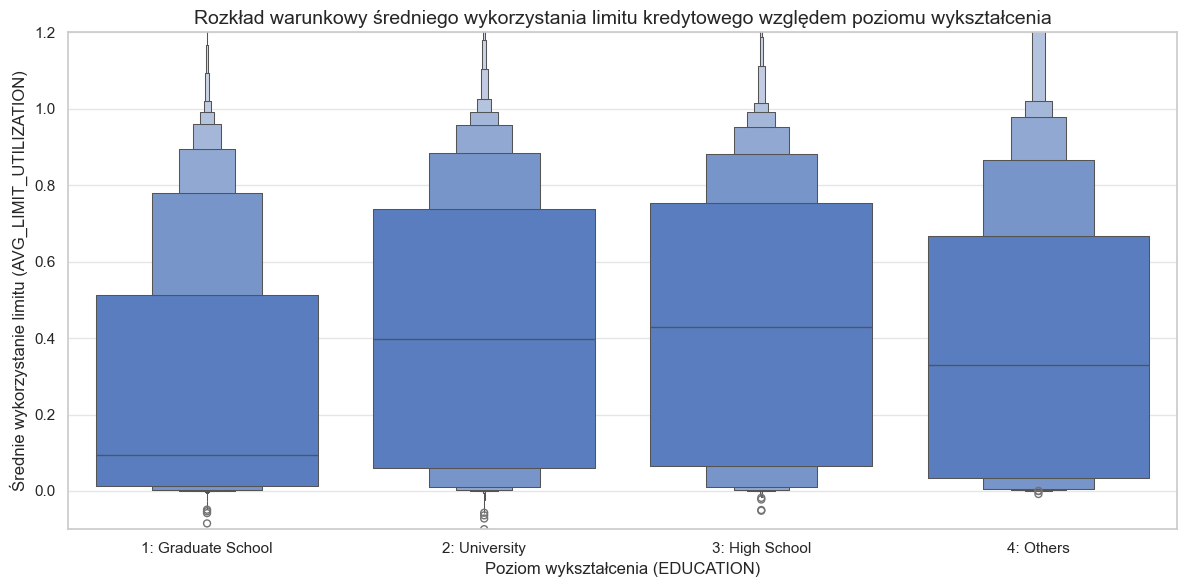

In [54]:
plt.figure(figsize=(12, 6))

# Mapowanie kodów dla czytelności wykresu
edu_mapping = {1: '1: Graduate School', 2: '2: University', 3: '3: High School', 4: '4: Others'}
plot_df = clustering_features.copy()
plot_df['EDUCATION_LAB'] = plot_df[variable_names[3]].map(edu_mapping)

# Wykres pudełkowy typu 'boxen' (wygodny dla dużych zbiorów danych do pokazania gęstości w ogonach)
sns.boxenplot(
    data=plot_df,
    x='EDUCATION_LAB',
    y='AVG_LIMIT_UTILIZATION',
    order=['1: Graduate School', '2: University', '3: High School', '4: Others']
)

plt.title('Rozkład warunkowy średniego wykorzystania limitu kredytowego względem poziomu wykształcenia')
plt.xlabel(f'Poziom wykształcenia ({variable_names[3]})')
plt.ylabel('Średnie wykorzystanie limitu (AVG_LIMIT_UTILIZATION)')
plt.ylim(-0.1, 1.2) # Zawężenie skali w celu eliminacji ekstremalnych anomalii dla lepszej czytelności
plt.tight_layout()
plt.show()


**Interpretacja do raportu:** Analiza rozkładu warunkowego nowej cechy `AVG_LIMIT_UTILIZATION` wykazała istotne różnice w zachowaniach finansowych podgrup wyznaczonych przez poziom wykształcenia (`EDUCATION`). Mediana oraz rozstęp kwartylowy (IQR) wskaźnika wykorzystania limitu rosną wraz ze spadkiem poziomu wykształcenia – osoby z wykształceniem średnim (High School) wykazują tendencję do znacznie intensywniejszego eksploatowania karty kredytowej (wartości bliższe 1.0) niż osoby po studiach doktoranckich czy magisterskich. Taka wielomodalność i zróżnicowanie rozkładów warunkowych potwierdza, że zmienna ta wnosi silny sygnał różnicujący, co będzie wysoce przydatne dla algorytmów klastrujących.

### Wykres 2: Identyfikacja interakcji między nowymi cechami (`PAY_MEAN` vs `AVG_LIMIT_UTILIZATION`)

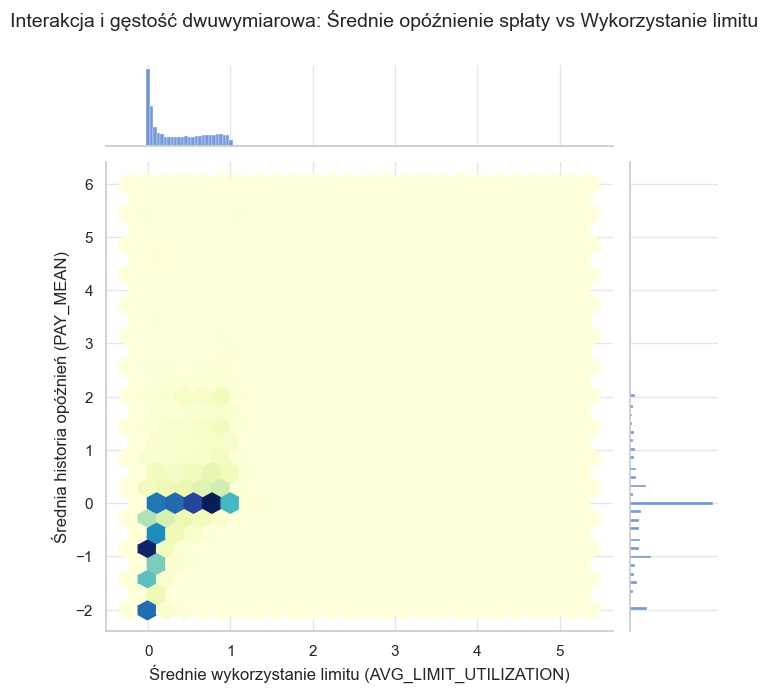

In [55]:
# Wykres rozrzutu z estymacją gęstości (jointplot) dla dwóch kluczowych agregatów behawioralnych
g = sns.jointplot(
    data=clustering_features,
    x='AVG_LIMIT_UTILIZATION',
    y='PAY_MEAN',
    kind="hex", # Wykres sześcianów gęstości (hexbin) świetnie oddaje zagęszczenie mas punktowych
    cmap="YlGnBu",
    gridsize=25,
    height=7
)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle('Interakcja i gęstość dwuwymiarowa: Średnie opóźnienie spłaty vs Wykorzystanie limitu', fontsize=14)
g.set_axis_labels('Średnie wykorzystanie limitu (AVG_LIMIT_UTILIZATION)', 'Średnia historia opóźnień (PAY_MEAN)', fontsize=12)

plt.show()


**Interpretacja do raportu:** Wizualizacja gęstości dwuwymiarowej (hexbin) ujawniła kluczową interakcję behawioralną. Największa koncentracja obserwacji (ciemne obszary) występuje w rejonie `PAY_MEAN` <= 0 oraz `AVG_LIMIT_UTILIZATION` < 0.2. Jest to dominująca grupa klientów stabilnych, rzetelnie spłacających zobowiązania. Zauważyć można jednak wyraźny "ogon" interakcji rozciągający się po przekątnej ku prawemu górnemu rogowi: klienci ze średnim opóźnieniem spłat powyżej 0 (`PAY_MEAN` > 0) niemal bezwyjątkowo charakteryzują się wysokim stopniem utylizacji limitu (> 0.6). Istnienie tak wyraźnie odseparowanych geometrycznie struktur w przestrzeni dwuwymiarowej stanowi empiryczny dowód na zasadność hipotezy o istnieniu naturalnych klastrów w tym zbiorze danych.